# NLP Project: Disaster Tweet Classification

Part 1: Data Exploration and Preparation

1. Importing Required Libraries

In [11]:
import re
import string
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

sns.set_style("whitegrid")
%matplotlib inline

2. Load the Dataset

In [3]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving twitter_disaster.xlsx to twitter_disaster.xlsx
User uploaded file "twitter_disaster.xlsx" with length 630855 bytes


In [6]:
df = pd.read_excel("twitter_disaster.xlsx")
print("Shape:", df.shape)
df.head()

Shape: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


3. Explore Dataset Structure

In [7]:
print("Columns:", df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate tweets (by text):", df["text"].duplicated().sum())

print("\nClass balance:")
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True).round(3))

Columns: ['id', 'keyword', 'location', 'text', 'target']

Data types:
id           int64
keyword     object
location    object
text        object
target       int64
dtype: object

Missing values:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Duplicate tweets (by text): 110

Class balance:
target
0    4342
1    3271
Name: count, dtype: int64
target
0    0.57
1    0.43
Name: proportion, dtype: float64


4. Class Distribution - Disaster vs. Non-Disaster

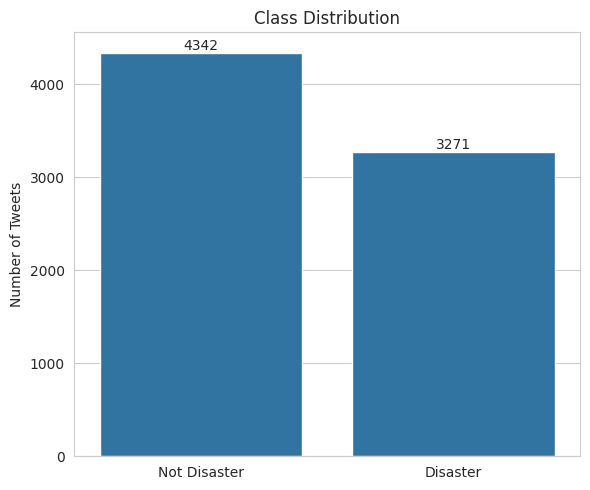

In [8]:
label_map = {0: "Not Disaster", 1: "Disaster"}
df["target_label"] = df["target"].map(label_map)

plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x="target_label", order=["Not Disaster", "Disaster"])
ax.set_title("Class Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of Tweets")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

5. Keyword Frequency Analysis

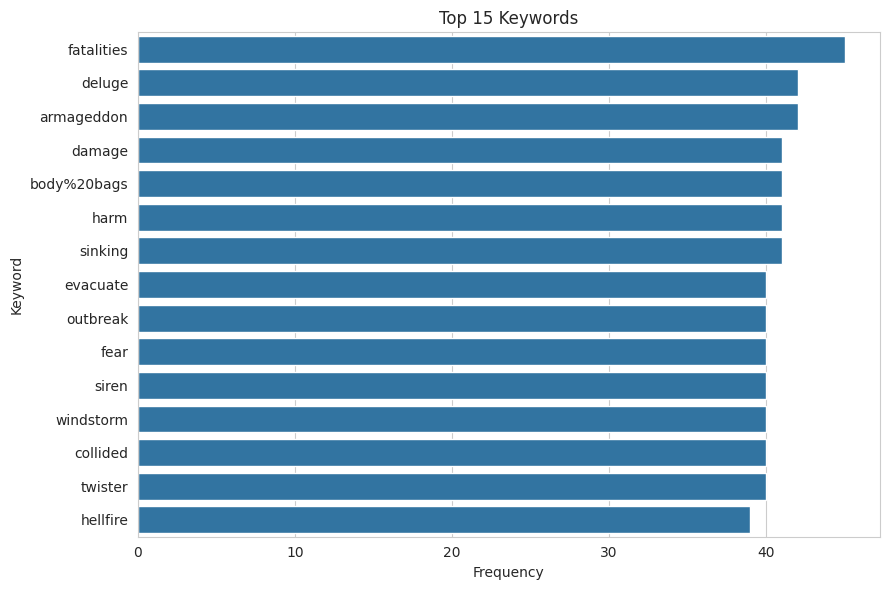

,mean,count
keyword,,
debris,1.000000,37
derailment,1.000000,39
wreckage,1.000000,39
outbreak,0.975000,40
oil%20spill,0.973684,38
typhoon,0.973684,38
suicide%20bombing,0.969697,33
suicide%20bomber,0.967742,31
bombing,0.931034,29


In [9]:
top_keywords = df["keyword"].value_counts().head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_keywords.values, y=top_keywords.index)
plt.title("Top 15 Keywords")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()


keyword_disaster_rate = (
    df.groupby("keyword")["target"]
    .agg(["mean", "count"])
    .query("count >= 20")
    .sort_values("mean", ascending=False)
    .head(15)
)
display(keyword_disaster_rate)

6. Tweet Length Distribution

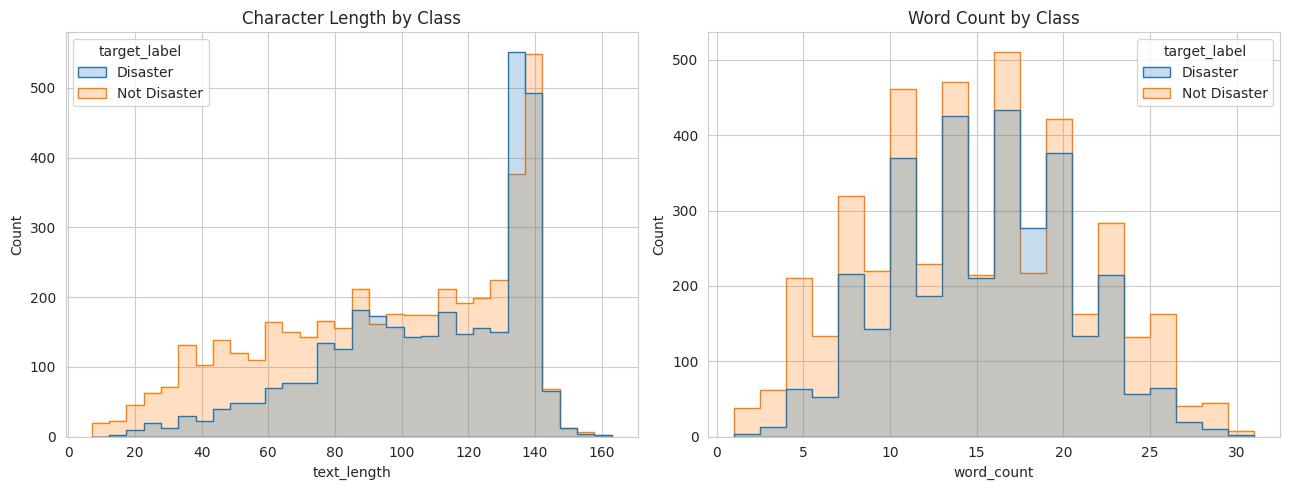

In [ ]:
df["text_length"] = df["text"].apply(len)
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df, x="text_length", hue="target_label", bins=30, element="step", ax=axes[0])
axes[0].set_title("Character Length by Class")

sns.histplot(data=df, x="word_count", hue="target_label", bins=20, element="step", ax=axes[1])
axes[1].set_title("Word Count by Class")

plt.tight_layout()
plt.show()

7. Cleaning the Text Data

In [14]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)   # URLs
    text = re.sub(r"@\w+", " ", text)                      # mentions
    text = re.sub(r"#", " ", text)                          # keep hashtag word, drop symbol
    text = re.sub(r"[^a-z\s]", " ", text)                   # punctuation / numbers
    text = re.sub(r"\s+", " ", text).strip()                # extra whitespace
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(10)

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed in both...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,i m on top of the hill and i can see a fire in...
8,There's an emergency evacuation happening now ...,there s an emergency evacuation happening now ...
9,I'm afraid that the tornado is coming to our a...,i m afraid that the tornado is coming to our area


8. Tokenization

In [15]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())
df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,our deeds are the reason of this earthquake ma...,"[our, deeds, are, the, reason, of, this, earth..."
1,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]"
2,all residents asked to shelter in place are be...,"[all, residents, asked, to, shelter, in, place..."
3,people receive wildfires evacuation orders in ...,"[people, receive, wildfires, evacuation, order..."
4,just got sent this photo from ruby alaska as s...,"[just, got, sent, this, photo, from, ruby, ala..."


9. Stop-Word Removal

In [16]:
stop_words = ENGLISH_STOP_WORDS  # avoids an nltk download; works fully offline

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 1]

df["tokens_no_stop"] = df["tokens"].apply(remove_stopwords)
df["clean_text_no_stop"] = df["tokens_no_stop"].apply(lambda toks: " ".join(toks))

df[["tokens", "tokens_no_stop", "clean_text_no_stop"]].head()

,tokens,tokens_no_stop,clean_text_no_stop
0,"[our, deeds, are, the, reason, of, this, earth...","[deeds, reason, earthquake, allah, forgive]",deeds reason earthquake allah forgive
1,"[forest, fire, near, la, ronge, sask, canada]","[forest, near, la, ronge, sask, canada]",forest near la ronge sask canada
2,"[all, residents, asked, to, shelter, in, place...","[residents, asked, shelter, place, notified, o...",residents asked shelter place notified officer...
3,"[people, receive, wildfires, evacuation, order...","[people, receive, wildfires, evacuation, order...",people receive wildfires evacuation orders cal...
4,"[just, got, sent, this, photo, from, ruby, ala...","[just, got, sent, photo, ruby, alaska, smoke, ...",just got sent photo ruby alaska smoke wildfire...


10. Most Frequent Words by Class

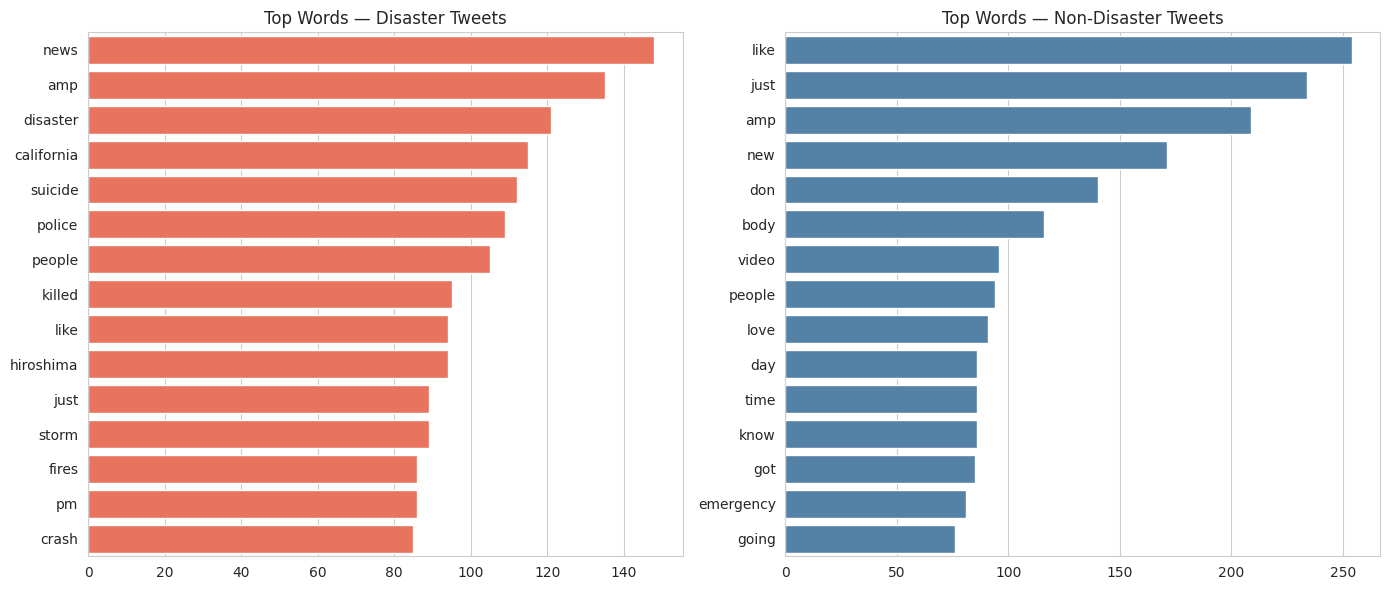

In [17]:
disaster_tokens = [t for toks in df.loc[df["target"] == 1, "tokens_no_stop"] for t in toks]
non_disaster_tokens = [t for toks in df.loc[df["target"] == 0, "tokens_no_stop"] for t in toks]

disaster_top = Counter(disaster_tokens).most_common(15)
non_disaster_top = Counter(non_disaster_tokens).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=[c for _, c in disaster_top], y=[w for w, _ in disaster_top], ax=axes[0], color="tomato")
axes[0].set_title("Top Words — Disaster Tweets")

sns.barplot(x=[c for _, c in non_disaster_top], y=[w for w, _ in non_disaster_top], ax=axes[1], color="steelblue")
axes[1].set_title("Top Words — Non-Disaster Tweets")

plt.tight_layout()
plt.show()

11. Train / Test Split

In [18]:
X = df["clean_text_no_stop"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 6090
Testing rows : 1523


Part 2: Feature Engineering and Model Selection

12. TF-IDF Feature Preview

In [19]:
tfidf_preview = TfidfVectorizer(max_features=20, stop_words="english")
X_preview = tfidf_preview.fit_transform(X_train)

print("Preview vocabulary:", tfidf_preview.get_feature_names_out())
print("Preview matrix shape:", X_preview.shape)

Preview vocabulary: ['amp' 'body' 'buildings' 'burning' 'day' 'disaster' 'don' 'emergency'
 'got' 'just' 'like' 'new' 'news' 'people' 'police' 'rt' 'storm' 'suicide'
 'time' 'video']
Preview matrix shape: (6090, 20)


13. Additional Engineered Features

In [ ]:
df["hashtag_count"] = df["text"].apply(lambda x: x.count("#"))
df["mention_count"] = df["text"].apply(lambda x: x.count("@"))
df["exclaim_count"] = df["text"].apply(lambda x: x.count("!"))
df["has_url"] = df["text"].str.contains(r"http", case=False, na=False).astype(int)

engineered = df.groupby("target_label")[
    ["text_length", "word_count", "hashtag_count", "mention_count", "exclaim_count", "has_url"]
].mean().round(2)

display(engineered)

,text_length,word_count,hashtag_count,mention_count,exclaim_count,has_url
target_label,,,,,,
Disaster,108.44,15.17,0.52,0.28,0.10,0.66
Not Disaster,95.98,14.70,0.39,0.43,0.19,0.41


14. Candidate Models with Cross-Validation

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Linear SVM": LinearSVC(max_iter=5000),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, clf in models.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("clf", clf),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="f1", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:28s} mean F1 = {scores.mean():.4f}  (+/- {scores.std():.4f})")

cv_df = pd.DataFrame(cv_results)

Logistic Regression          mean F1 = 0.7353  (+/- 0.0050)
Multinomial Naive Bayes      mean F1 = 0.7270  (+/- 0.0082)
Random Forest                mean F1 = 0.7205  (+/- 0.0167)
Linear SVM                   mean F1 = 0.7258  (+/- 0.0100)


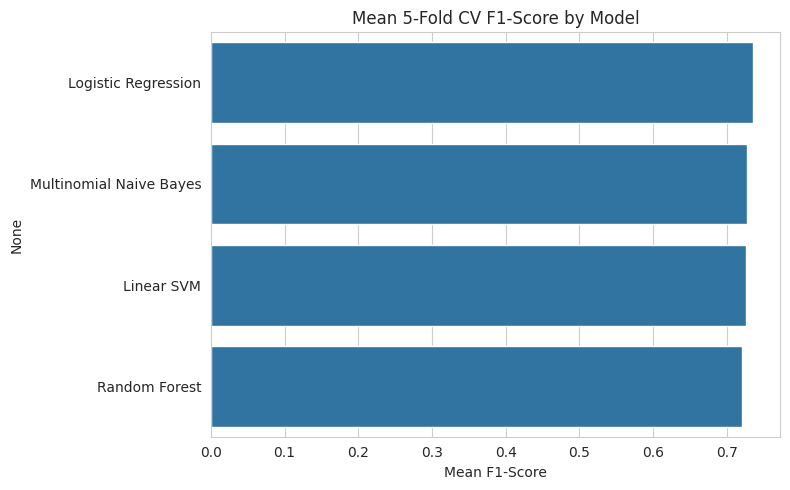

In [22]:
plt.figure(figsize=(8, 5))
mean_scores = cv_df.mean().sort_values(ascending=False)
sns.barplot(x=mean_scores.values, y=mean_scores.index)
plt.title("Mean 5-Fold CV F1-Score by Model")
plt.xlabel("Mean F1-Score")
plt.tight_layout()
plt.show()

15. Hyperparameter Tuning

In [23]:
best_model_name = cv_df.mean().idxmax()
print("Best model from cross-validation:", best_model_name)

param_grid = {
    "tfidf__max_features": [3000, 5000, 8000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1, 10],
}

tuning_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000)),
])

grid_search = GridSearchCV(
    tuning_pipeline, param_grid, cv=3, scoring="f1", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1 :", round(grid_search.best_score_, 4))

best_pipeline = grid_search.best_estimator_

Best model from cross-validation: Logistic Regression
Best params: {'clf__C': 1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
Best CV F1 : 0.7326


Part 3: Model Evaluation and Validation

16. Evaluate on the Held-Out Test Set

In [24]:
y_pred = best_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Not Disaster", "Disaster"]))

Accuracy : 0.8207
Precision: 0.8408
Recall   : 0.7187
F1-score : 0.7749

Classification report:
              precision    recall  f1-score   support

Not Disaster       0.81      0.90      0.85       869
    Disaster       0.84      0.72      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523



17. Confusion Matrix

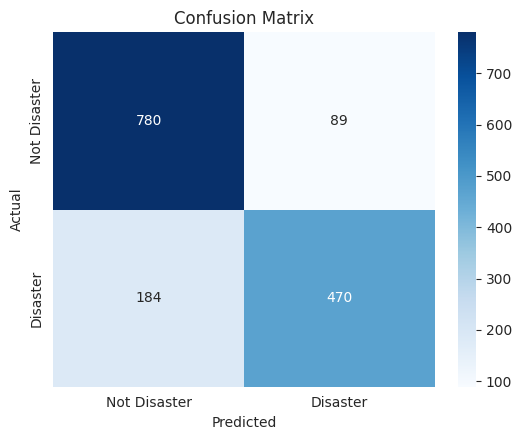

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not Disaster", "Disaster"],
    yticklabels=["Not Disaster", "Disaster"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

18. ROC Curve

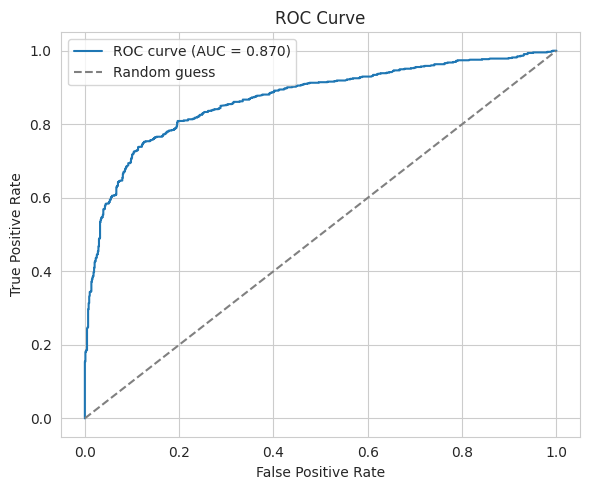

In [26]:
if hasattr(best_pipeline.named_steps["clf"], "predict_proba"):
    y_score = best_pipeline.predict_proba(X_test)[:, 1]
else:
    y_score = best_pipeline.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

19. Precision-Recall Curve

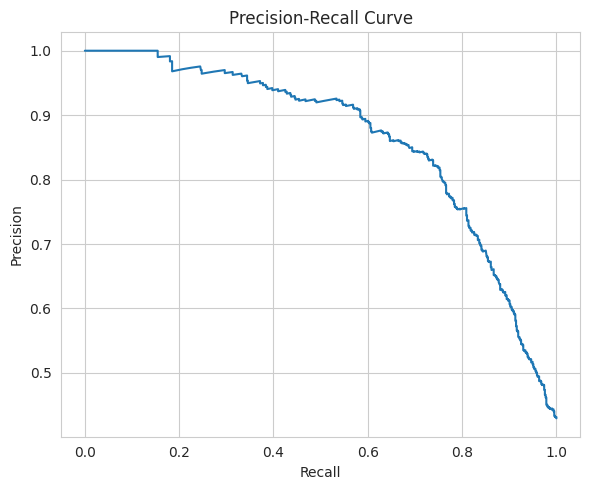

In [27]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_score)

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

20. Validation: Overfitting / Underfitting

In [29]:
train_pred = best_pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

print(f"Training accuracy        : {train_accuracy:.4f}")
print(f"Cross-validation F1 (best): {grid_search.best_score_:.4f}")
print(f"Test accuracy             : {accuracy:.4f}")
print(f"Test F1-score             : {f1:.4f}")

gap = train_accuracy - accuracy
print(f"\nTrain-test accuracy gap: {gap:.4f}")
if gap > 0.15:
    print("Gap is large - model may be overfitting.")
else:
    print("Gap is modest - model generalizes reasonably well.")

Training accuracy        : 0.8606
Cross-validation F1 (best): 0.7326
Test accuracy             : 0.8207
Test F1-score             : 0.7749

Train-test accuracy gap: 0.0398
Gap is modest - model generalizes reasonably well.


21. Error Analysis

In [30]:
results_df = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred,
})
results_df["actual_label"] = results_df["actual"].map(label_map)
results_df["predicted_label"] = results_df["predicted"].map(label_map)

misclassified = results_df[results_df["actual"] != results_df["predicted"]]
print(f"Misclassified tweets: {len(misclassified)} out of {len(results_df)}")

misclassified[["text", "actual_label", "predicted_label"]].sample(
    min(10, len(misclassified)), random_state=42
)

Misclassified tweets: 273 out of 1523


,text,actual_label,predicted_label
264,stop annihilation salt river wild horses,Disaster,Not Disaster
2725,richmond coaches devastated hear death second ...,Disaster,Not Disaster
243,hell just fraction belief total annihilation d...,Disaster,Not Disaster
2991,bg far brunt storm just north grayed dust amp ...,Not Disaster,Disaster
2773,fascinating pics inside north korea propaganda...,Not Disaster,Disaster
90,accident,Not Disaster,Disaster
2493,ty follow brutally abused desolate amp lost lo...,Disaster,Not Disaster
5800,time high profile signing nffc city rioting we...,Disaster,Not Disaster
61,progressive greetings month students set pens ...,Not Disaster,Disaster
2961,london drowning iiii live riveeeeeer,Disaster,Not Disaster


Part 4: Deployment Preparation

22. Saving the Trained Model

In [31]:
with open("disaster_tweet_model.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

print("Model saved to disaster_tweet_model.pkl")

Model saved to disaster_tweet_model.pkl


23. Prediction Function

In [32]:
def predict_tweet(text, pipeline=best_pipeline):
    cleaned = clean_text(text)
    tokens = [t for t in cleaned.split() if t not in stop_words and len(t) > 1]
    cleaned = " ".join(tokens)
    prediction = pipeline.predict([cleaned])[0]
    return "Disaster" if prediction == 1 else "Not Disaster"

sample_tweets = [
    "Massive earthquake hits the city, buildings collapsed and people trapped",
    "This concert was a total disaster, worst sound quality ever",
    "Wildfire spreading fast near the highway, evacuation ordered now",
    "just watched a great movie about a plane crash lol",
]

for tweet in sample_tweets:
    print(f"Tweet:      {tweet}")
    print(f"Prediction: {predict_tweet(tweet)}\n")

Tweet:      Massive earthquake hits the city, buildings collapsed and people trapped
Prediction: Disaster

Tweet:      This concert was a total disaster, worst sound quality ever
Prediction: Not Disaster

Tweet:      Wildfire spreading fast near the highway, evacuation ordered now
Prediction: Disaster

Tweet:      just watched a great movie about a plane crash lol
Prediction: Not Disaster

